# 5.9 Midterm Practice 70pts
From Sophin 10/30/25:<p>
This is an old copy of the solution I got. But frankly, I do not fully understand why the solution applied  'Gradient Descent' for the question - Let’s try determining the type of disease based on the patient’s Age.

Since the type of disease is a categorical variable, then we shall use classification models such as 'Logistic Regression'. As a result, the correct approach is gradient ascent . If you feel unsure about grading this question, feel free to leave it to me. I told the class that 'Gradient Ascent' is the option to explore.

# Q0 import packages and load data

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [43]:
dermatology = pd.read_csv("dermatology.csv", sep = "\t")
dermatology.head()

,Erythema,Scathing,Definite Borders,Itching,Koebner,Polygonal,Follicular,Oral,Knee,Scalp,...,Disapperance,Vacuolisation,Spongiosis,Retes,Follicular.1,Perifollicular,Inflamatory,Band-like,Age,Disease
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [44]:
dermatology.shape

(366, 35)

In [45]:
hatecrime = pd.read_csv("hatecrime.csv")
hatecrime.head()

,state,median_household_income,share_unemployed_seasonal,share_population_in_metro_areas,share_population_with_high_school_degree,share_non_citizen,share_white_poverty,gini_index,share_non_white,share_voters_voted_trump,hate_crimes_per_100k_splc,avg_hatecrimes_per_100k_fbi
0,Alabama,42278,0.060,0.64,0.821,0.02,0.12,0.472,0.35,0.63,0.125839,1.806410
1,Alaska,67629,0.064,0.63,0.914,0.04,0.06,0.422,0.42,0.53,0.143740,1.656700
2,Arizona,49254,0.063,0.90,0.842,0.10,0.09,0.455,0.49,0.50,0.225320,3.413928
3,Arkansas,44922,0.052,0.69,0.824,0.04,0.12,0.458,0.26,0.60,0.069061,0.869209
4,California,60487,0.059,0.97,0.806,0.13,0.09,0.471,0.61,0.33,0.255805,2.397986


# Problem 1
Attached is a dataset from a study in a dermatology department. Following are the attributes used in it.

**Clinical Attributes: (take values 0, 1, 2, 3, unless otherwise indicated)**  
1 Erythema  
2 Scaling  
3 definite borders  
4 Itching  
5 koebner phenomenon  
6 polygonal papules  
7 follicular papules  
8 oral mucosal involvement  
9 knee and elbow involvement  
10 scalp involvement  
11 family history (0 or 1)  
34 Age  

**Histopathological Attributes: (take values 0, 1, 2, 3)**  
12 melanin incontinence  
13 eosinophils in the infiltrate  
14 PNL infiltrate  
15 fibrosis of the papillary dermis  
16 Exocytosis  
17 Acanthosis  
18 Hyperkeratosis  
19 Parakeratosis  
20 clubbing of the rete ridges  
21 elongation of the rete ridges  
22 thinning of the suprapapillary epidermis  
23 spongiform pustule  
24 munro microabcess  
25 focal hypergranulosis  
26 disappearance of the granular layer  
27 vacuolisation and damage of basal layer  
28 Spongiosis  
29 saw-tooth appearance of retes  
30 follicular horn plug  
31 perifollicular parakeratosis  
32 inflammatory monoluclear inflitrate  
33 band-like infiltrate

This database contains 34 attributes. **35th is the class label, i.e. the disease name**. The names and id numbers of the patients were removed from the database.

The differential diagnosis of erythemato-squamous diseases is a real problem in dermatology. They all share the clinical features of erythema and scaling, with very little differences. The diseases in this group are psoriasis, seboreic dermatitis, lichen planus, pityriasis rosea, cronic dermatitis, and pityriasis rubra pilaris. Usually a biopsy is necessary for the diagnosis but unfortunately these diseases share many histopathological features as well. Another difficulty for the differential diagnosis is that a disease may show the features of another disease at the beginning stage and may have the characteristic features at the following stages. Patients were first evaluated clinically with 12 features. Afterwards, skin samples were taken for the evaluation of 22 histopathological features. The values of the histopathological features are determined by an analysis of the samples under a microscope.

In the dataset constructed for this domain, the family history feature has the value 1 if any of these diseases has been observed in the family, and 0 otherwise. The age feature simply represents the age of the patient. Every other feature (clinical and histopathological) was given a degree in the range of 0 to 3. **Here, 0 indicates that the feature was not present, 3 indicates the largest amount possible, and 1, 2 indicate the relative intermediate values.**

Assuming that the list of diseases in this group are complete (total 6 types), use the dataset to address the following list of objectives:



### Q1-1 Let’s try determining the type of disease based on the patient’s Age. Use gradient descent (GD) to build your regression model (model1). Start by writing the GD algorithm and then implement it using a programming language of your choice. [10 points]
<b>See note above, should be Gradient Ascent</b>

In [46]:
def softmax(x):
    x = x - x.max(axis=1, keepdims=True)  
    ez = np.exp(x)
    return ez / ez.sum(axis=1, keepdims=True)

In [47]:
dermatology.columns

Index(['Erythema', 'Scathing', 'Definite Borders', 'Itching', 'Koebner ',
       'Polygonal', 'Follicular', 'Oral', 'Knee', 'Scalp', 'Family Hostory',
       'Melanin', 'Eosinophils', 'PNL', 'Fibrosis', 'Exocytosis',
       'Acanothosis', 'Hyperkeratosis', 'Parakeratosis', 'Clubbing',
       'Elongation', 'Thinning', 'Spongiform', 'Munro', 'Focal',
       'Disapperance', 'Vacuolisation', 'Spongiosis', 'Retes', 'Follicular.1',
       'Perifollicular', 'Inflamatory', 'Band-like', 'Age', 'Disease'],
      dtype='object')

In [48]:
#Creating the linear model and printing it's summary
lr_model = smf.ols(formula = 'Disease ~ Age', data = dermatology).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Disease   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     2.071
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           3.53e-05
Time:                        22:05:09   Log-Likelihood:                -627.82
No. Observations:                 366   AIC:                             1378.
Df Residuals:                     305   BIC:                             1616.
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0000      1.473      0.679      0.498      -1.899       3.899
Age[T.10]      3.1429      1.575      1.995      0.047       0.043       6.242
Age[T.12]      4.3333      1.701      2.547      0.011       0.985       7.681
Age[T.13]      5.0000      1.805      2.771      0.006       1.449       8.551
Age[T.15]      0.5000      1.805      0.277      0.782      -3.051       4.051
Age[T.16]      3.0000      1.614      1.859      0.064      -0.176       6.176
Age[T.17]      3.0000      1.614      1.859      0.064      -0.176       6.176
Age[T.18]      2.2222      1.553      1.431      0.154      -0.834       5.278
Age[T.19]      1.5000      1.591      0.943      0.347      -1.632       4.632
Age[T.20]      0.8750      1.563      0.560      0.576      -2.200       3.950
Age[T.21]      1.3333      1.701      0.784      0.434      -2.015       4.681
Age[T.22]      2.0667      1.522      1.358      0.175      -0.928       5.061
Age[T.23]      1.0000      1.701      0.588      0.557      -2.348       4.348
Age[T.24]   4.596e-14      1.805   2.55e-14      1.000      -3.551       3.551
Age[T.25]      1.9286      1.525      1.265      0.207      -1.073       4.930
Age[T.26]      2.0000      1.701      1.176      0.241      -1.348       5.348
Age[T.27]      1.5000      1.519      0.988      0.324      -1.489       4.489
Age[T.28]      2.0000      1.614      1.239      0.216      -1.176       5.176
Age[T.29]      2.0000      1.701      1.176      0.241      -1.348       5.348
Age[T.30]      1.6923      1.529      1.107      0.269      -1.316       4.701
Age[T.31]      2.0000      1.805      1.108      0.269      -1.551       5.551
Age[T.32]      2.1667      1.591      1.361      0.174      -0.965       5.298
Age[T.33]      0.7500      1.534      0.489      0.625      -2.268       3.768
Age[T.34]      1.5000      1.563      0.960      0.338      -1.575       4.575
Age[T.35]      2.2143      1.525      1.452      0.148      -0.787       5.215
Age[T.36]      1.8125      1.519      1.193      0.234      -1.176       4.801
Age[T.37]      1.5000      1.805      0.831      0.406      -2.051       5.051
Age[T.38]      0.6667      1.701      0.392      0.695      -2.681       4.015
Age[T.39]      2.0000      1.805      1.108      0.269      -1.551       5.551
Age[T.40]      1.8824      1.516      1.242      0.215      -1.101       4.866
Age[T.41]      0.7500      1.647      0.455      0.649      -2.492       3.992
Age[T.42]      1.6000      1.545      1.035      0.301      -1.441       4.641
Age[T.43]      0.5000      1.647      0.304      0.762      -2.742       3.742
Age[T.44]      2.0000      1.614      1.239      0.216      -1.176       5.176
Age[T.45]      1.8571      1.575      1.179      0.239      -1.242       4.957
Age[T.46]      1.6667      1.591      1.047      0.296      -1.465       4.798
Ag

In [49]:
df = dermatology[['Age', 'Disease']].copy()

# Coerce to numeric; "?" -> NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Disease'] = pd.to_numeric(df['Disease'], errors='coerce')

# Drop rows with missing numeric values
df = df.dropna(subset=['Age', 'Disease'])

# Define X (with intercept) & y as numpy arrays
X = sm.add_constant(df['Age'].to_numpy(dtype=np.float64))  # shape (n, 2)
y = df['Disease'].to_numpy(dtype=np.float64).reshape(-1, 1)  # shape (n, 1)

def grad_descent(X, y, alpha, epsilon):
    # Standardize X columns (const will be scaled too, that's fine for this demo)
    Xs = preprocessing.scale(X.astype(np.float64))  # ensure float, no "?"
    
    # Initialize
    theta = np.ones((Xs.shape[1], 1))              # (2,1)
    # initial cost (scalar)
    resid = Xs @ theta - y
    cost = [float((resid.T @ resid).item())]
    delta = np.inf
    i = 0
    
    # Gradient descent loop
    Xt = Xs.T
    while delta > epsilon:
        grad = Xt @ (Xs @ theta - y)               # (2,1)
        theta = theta - alpha * grad
        resid = Xs @ theta - y
        cval = float((resid.T @ resid).item())
        cost.append(cval)
        delta = abs(cost[-1] - cost[-2])
        if cost[-1] > cost[-2]:
            print("The cost is increasing. Try reducing alpha.")
            break
        i += 1
    
    print(f"Completed in {i} iterations.")
    return theta, cost

theta, cost = grad_descent(X=X, y=y, alpha=1e-4, epsilon=1e-10)
print(theta)

Completed in 371 iterations.
[[ 1.        ]
 [-0.40355665]]


In [50]:
# preprocessing
print(dermatology["Age"].dtype)
print(dermatology['Age'].loc[dermatology['Age']=="?"].count())
# assign values to "?" & the type of Age
mean = dermatology['Age'].loc[dermatology['Age']!="?"].astype(int).mean()
print(mean)
dermatology.loc[dermatology['Age']=="?", 'Age'] = mean
dermatology['Age'] = dermatology['Age'].astype(int)

object
8
36.29608938547486


In [51]:
# print(dermatology["Age"].mean())
# option 2: impute the average
dermatology.loc[dermatology['Age']=="?", 'Age'] = dermatology["Age"].mean()
dermatology['Age'] = dermatology['Age'].astype(int)

/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/ipykernel_86909/1933310522.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '36.2896174863388' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dermatology.loc[dermatology['Age']=="?", 'Age'] = dermatology["Age"].mean()


### Q1-2 Use random forest on the clinical as well as histopathological attributes to classify the disease type (model2). [5 points]

In [52]:
X = dermatology.iloc[:,:-1]
y = dermatology.iloc[:,-1]
acc_list = []
for i in range(200):
    #Creating X and Y for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
    rfc = RandomForestClassifier(n_estimators=100)
    # y_train is a column vector, but 1d array is expected. Therefore, we need to change the shape to (n_samples,)
    rfc.fit(X_train, y_train.values.ravel())
    predictions = rfc.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    acc_list.append(accuracy)
df_acc = pd.DataFrame(acc_list, columns = ["accuracy"])
print (df_acc)
df_acc.describe()

     accuracy
0    0.963636
1    0.981818
2    0.954545
3    0.963636
4    0.981818
..        ...
195  0.990909
196  0.981818
197  0.972727
198  0.963636
199  0.981818

[200 rows x 1 columns]


,accuracy
count,200.000000
mean,0.973500
std,0.013231
min,0.927273
25%,0.963636
50%,0.972727
75%,0.981818
max,1.000000


<Axes: ylabel='accuracy'>

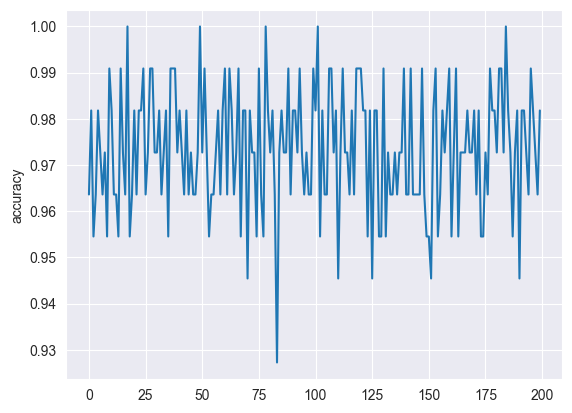

In [53]:
sns.lineplot(data=df_acc["accuracy"])

### Q1-3 Use kNN on the clinical attributes and histopathological attributes to classify the disease type and report your accuracy (model3). [5 points]

In [54]:
X = preprocessing.scale(dermatology.iloc[:,:-1])

acc_list = []
for i in range(100):
    #Creating X and Y for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
    
    k_acc_record = []
    for k in range(2, 11):
        #Creating KNN Classfier model
        knn = KNeighborsClassifier(n_neighbors=k)

        #Fitting the training data
        knn.fit(X_train,y_train)

        #Predicting on the test data
        predictions = knn.predict(X_test)

        accuracy = accuracy_score(y_test,predictions)
        
        k_acc_record.append(accuracy)
    acc_list.append(k_acc_record)

In [55]:
cols = ["k_"+str(i) for i in range(2,11)]
df_acc = pd.DataFrame(acc_list, columns = cols)
df_acc.describe()

,k_2,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.943455,0.954364,0.959364,0.957727,0.959455,0.956000,0.957000,0.954000,0.956091
std,0.019016,0.016445,0.017018,0.016965,0.017784,0.017656,0.017944,0.018982,0.018638
min,0.881818,0.918182,0.918182,0.918182,0.918182,0.918182,0.909091,0.909091,0.909091
25%,0.927273,0.945455,0.945455,0.945455,0.945455,0.945455,0.945455,0.943182,0.945455
50%,0.945455,0.954545,0.963636,0.954545,0.963636,0.954545,0.963636,0.954545,0.954545
75%,0.954545,0.963636,0.972727,0.972727,0.972727,0.972727,0.972727,0.963636,0.965909
max,0.990909,0.981818,1.000000,0.990909,1.000000,0.981818,1.000000,0.990909,0.990909


### Q1-4 Finally, use two different clustering algorithms and see how well these attributes can determine the disease type (model4 and model5). [10 points]

In [56]:
X = dermatology.iloc[:,:34]
X

,Erythema,Scathing,Definite Borders,Itching,Koebner,Polygonal,Follicular,Oral,Knee,Scalp,...,Focal,Disapperance,Vacuolisation,Spongiosis,Retes,Follicular.1,Perifollicular,Inflamatory,Band-like,Age
0,2,2,0,3,0,0,0,0,1,0,...,0,0,0,3,0,0,0,1,0,55
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,8
2,2,1,2,3,1,3,0,3,0,0,...,2,0,2,3,2,0,0,2,3,26
3,2,2,2,0,0,0,0,0,3,2,...,0,3,0,0,0,0,0,3,0,40
4,2,3,2,2,2,2,0,2,0,0,...,2,2,3,2,3,0,0,2,3,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,2,0,25
362,3,2,1,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,2,0,36
363,3,2,2,2,3,2,0,2,0,0,...,3,0,3,0,3,0,0,2,3,28
364,2,1,3,1,2,3,0,2,0,0,...,3,0,2,0,1,0,0,2,3,50


In [57]:
## model 4: kmean
X = dermatology.iloc[:,:-1]
num_group = len(dermatology.Disease.groupby(dermatology.Disease).count())
print("# groups:", num_group)
scaler = preprocessing.StandardScaler()

kmeans = KMeans(n_clusters=num_group)

# Fitting the model
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# groups: 6


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [58]:
## model 5 Agglomerative Clustering
ac = AgglomerativeClustering(n_clusters = num_group) 
y_ac = ac.fit_predict(X)

In [59]:
temp_dict = {"y": y, "y_kmeans": y_kmeans, "y_ac": y_ac}
result = pd.DataFrame(temp_dict)
result["y"].value_counts(), result["y_kmeans"].value_counts(), result["y_ac"].value_counts()

(y
 1    112
 3     72
 2     61
 5     52
 4     49
 6     20
 Name: count, dtype: int64,
 y_kmeans
 4    122
 0     82
 2     59
 1     45
 3     31
 5     27
 Name: count, dtype: int64,
 y_ac
 0    115
 3     68
 1     58
 4     57
 2     45
 5     23
 Name: count, dtype: int64)

## Problem 2
Attached is a dataset containing statistics of hate crimes that happened within 10 days of 2016 US elections. In that period, nearly 900 hate incidents were reported to the Southern Poverty Law Center, averaging out to 90 per day. By comparison, about 36,000 hate crimes were reported to the FBI from 2010 through 2015 — an average of 16 per day.

The numbers we have here are tricky; the data is limited by how it’s collected and can’t definitively tell us whether there were more hate incidents in the days after the election than is typical. What we can do, however, is to look for trends within the numbers, such as how hate crimes vary by state, as well as what factors within those states might be tied to hate crime rates.

Following are the description of variables that are part of the dataset:

| Header                                   | Definition                                                                       |
|------------------------------------------|----------------------------------------------------------------------------------|
| State                                    | State name                                                                       |
| median_household_income                  | Median household income, 2016                                                    |
| share_unemployed_seasonal                | Share of the population that is unemployed (seasonally adjusted), Sept. 2016     |
| share_population_in_metro_areas          | Share of the population that lives in metropolitan areas, 2015                   |
| share_population_with_high_school_degree | Share of adults 25 and older with a high-school degree, 2009                     |
| share_non_citizen                        | Share of the population that are not U.S. citizens, 2015                         |
| share_white_poverty                      | Share of white residents who are living in poverty, 2015                         |
| gini_index                               | Gini Index, 2015                                                                 |
| share_non_white                          | Share of the population that is not white, 2015                                  |
| share_voters_voted_trump                 | Share of 2016 U.S. presidential voters who voted for Donald Trump                |
| hate_crimes_per_100k_splc                | Hate crimes per 100,000 population, Southern Poverty Law Center, Nov. 9-18, 2016 |
| avg_hatecrimes_per_100k_fbi              | Average annual hate crimes per 100,000 population, FBI, 2010-2015                |

Use this data to answer the following questions. Use appropriate machine learning techniques/algorithms.

### Q2a (2-1) How does income inequality relate to the number of hate crimes and hate incidents? [5 points]

In [60]:
# examine the data
hatecrime.isna().sum()

state                                       0
median_household_income                     0
share_unemployed_seasonal                   0
share_population_in_metro_areas             0
share_population_with_high_school_degree    0
share_non_citizen                           3
share_white_poverty                         0
gini_index                                  0
share_non_white                             0
share_voters_voted_trump                    0
hate_crimes_per_100k_splc                   4
avg_hatecrimes_per_100k_fbi                 1
dtype: int64

In [61]:
## preprocessing
nan_list = ["share_non_citizen", "hate_crimes_per_100k_splc", "avg_hatecrimes_per_100k_fbi"]
for col_name in nan_list:
    mean = hatecrime[col_name].mean()
    hatecrime[col_name] = hatecrime[col_name].fillna(mean)
hatecrime.isna().sum()

state                                       0
median_household_income                     0
share_unemployed_seasonal                   0
share_population_in_metro_areas             0
share_population_with_high_school_degree    0
share_non_citizen                           0
share_white_poverty                         0
gini_index                                  0
share_non_white                             0
share_voters_voted_trump                    0
hate_crimes_per_100k_splc                   0
avg_hatecrimes_per_100k_fbi                 0
dtype: int64

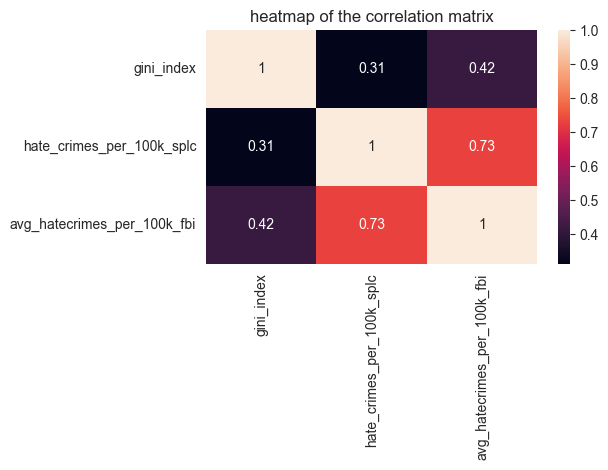

In [62]:
corr_matrix = hatecrime[["gini_index", "hate_crimes_per_100k_splc", "avg_hatecrimes_per_100k_fbi"]].corr()
plot1 = sns.heatmap(corr_matrix, annot=True)
plot1.set_title("heatmap of the correlation matrix")
plt.tight_layout()

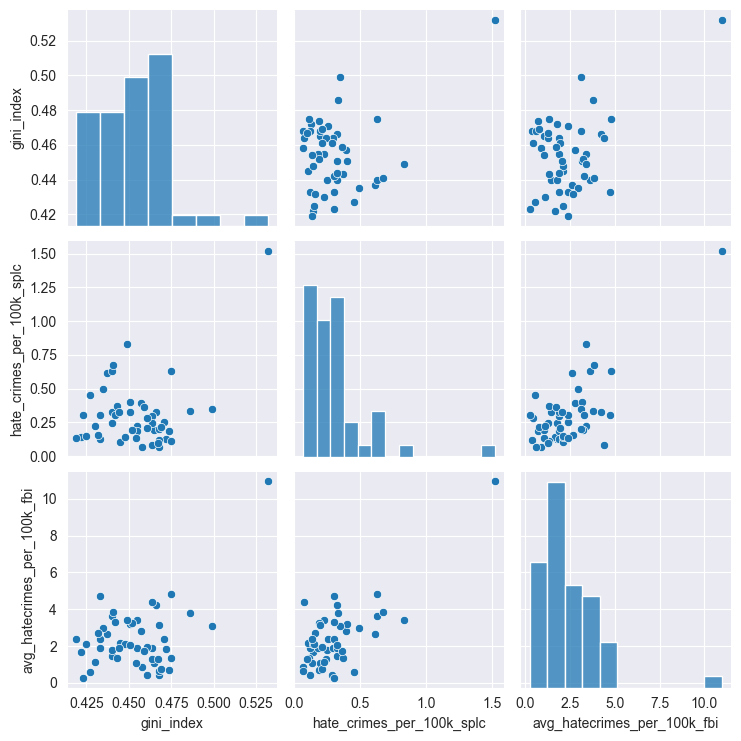

In [63]:
# Basic correlogram
sns.pairplot(hatecrime[["gini_index", "hate_crimes_per_100k_splc", "avg_hatecrimes_per_100k_fbi"]])
plt.show()

In [64]:
#Creating the linear model and printing it's summary
lr_model = smf.ols(formula = 'avg_hatecrimes_per_100k_fbi ~ gini_index', data = hatecrime).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     avg_hatecrimes_per_100k_fbi   R-squared:                       0.174
Model:                                     OLS   Adj. R-squared:                  0.157
Method:                          Least Squares   F-statistic:                     10.31
Date:                         Thu, 30 Oct 2025   Prob (F-statistic):            0.00233
Time:                                 22:05:18   Log-Likelihood:                -93.962
No. Observations:                           51   AIC:                             191.9
Df Residuals:                               49   BIC:                             195.8
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -13.0034      4.791     -2.714      0.009     -22.631      -3.375
gini_index    33.8745     10.548      3.212      0.002      12.678      55.071
==============================================================================
Omnibus:                       16.216   Durbin-Watson:                   2.383
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.832
Skew:                           1.030   Prob(JB):                     6.68e-06
Kurtosis:                       5.640   Cond. No.                         58.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [65]:
#Creating the linear model and printing its summary
lr_model = smf.ols(formula = 'hate_crimes_per_100k_splc ~ gini_index', data = hatecrime).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.098
Model:                                   OLS   Adj. R-squared:                  0.080
Method:                        Least Squares   F-statistic:                     5.330
Date:                       Thu, 30 Oct 2025   Prob (F-statistic):             0.0252
Time:                               22:05:18   Log-Likelihood:                 3.0496
No. Observations:                         51   AIC:                            -2.099
Df Residuals:                             49   BIC:                             1.764
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3449      0.715     -1.881      0.066      -2.782       0.092
gini_index     3.6340      1.574      2.309      0.025       0.471       6.797
==============================================================================
Omnibus:                       29.444   Durbin-Watson:                   2.064
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               60.302
Skew:                           1.731   Prob(JB):                     8.05e-14
Kurtosis:                       7.049   Cond. No.                         58.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Q2b (2-2) How can we predict the number of hate crimes and hate incidents from race/nature of the population? [5 points]

#### when y = 'hate_crimes_per_100k_splc'

In [66]:
y = hatecrime['hate_crimes_per_100k_splc']
X = hatecrime[['share_unemployed_seasonal', 'share_population_in_metro_areas', 'share_population_with_high_school_degree',
               'share_non_citizen', 'share_white_poverty', 'share_non_white', 'share_voters_voted_trump']]

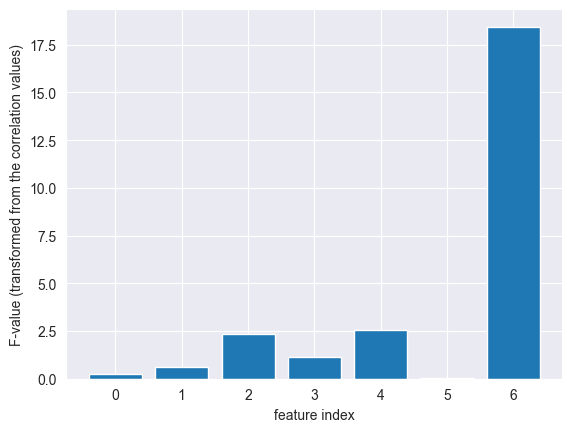

In [67]:
# Feature selection using the Correlation metric

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# feature selection
f_selector = SelectKBest(score_func=f_regression, k='all')
# learn relationship from training data
f_selector.fit(X_train, y_train)
# transform train input data
X_train_fs = f_selector.transform(X_train)
# transform test input data
X_test_fs = f_selector.transform(X_test)
# Plot the scores for the features
plt.bar([i for i in range(len(f_selector.scores_))], f_selector.scores_)
plt.xlabel("feature index")
plt.ylabel("F-value (transformed from the correlation values)")
plt.show()

In [68]:
#test 1
#Creating the linear model and printing it's summary
X = hatecrime[['share_unemployed_seasonal']]
X = sm.add_constant(X)
lr_model = sm.OLS(y, X).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.006
Model:                                   OLS   Adj. R-squared:                 -0.015
Method:                        Least Squares   F-statistic:                    0.2767
Date:                       Thu, 30 Oct 2025   Prob (F-statistic):              0.601
Time:                               22:05:18   Log-Likelihood:                0.56033
No. Observations:                         51   AIC:                             2.879
Df Residuals:                             49   BIC:                             6.743
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.2199      0.164      1.344      0.185      -0.109       0.549
share_unemployed_seasonal     1.6977      3.228      0.526      0.601      -4.788       8.184
==============================================================================
Omnibus:                       51.807   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              265.454
Skew:                           2.663   Prob(JB):                     2.28e-58
Kurtosis:                      12.826   Cond. No.                         94.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
#test 2
#Creating the linear model and printing its summary
X = hatecrime[['share_voters_voted_trump']]
X = sm.add_constant(X)
lr_model = sm.OLS(y, X).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.357
Model:                                   OLS   Adj. R-squared:                  0.344
Method:                        Least Squares   F-statistic:                     27.24
Date:                       Thu, 30 Oct 2025   Prob (F-statistic):           3.63e-06
Time:                               22:05:18   Log-Likelihood:                 11.689
No. Observations:                         51   AIC:                            -19.38
Df Residuals:                             49   BIC:                            -15.51
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.9021      0.118      7.656      0.000       0.665       1.139
share_voters_voted_trump    -1.2205      0.234     -5.219      0.000      -1.690      -0.751
==============================================================================
Omnibus:                       12.451   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.038
Skew:                           1.030   Prob(JB):                      0.00147
Kurtosis:                       4.374   Cond. No.                         10.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
#test 3
#Creating the linear model and printing it's summary
X = hatecrime[[ 'share_population_with_high_school_degree',
               'share_non_citizen','share_white_poverty', 'share_voters_voted_trump']]
X = sm.add_constant(X)
lr_model = sm.OLS(y, X).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.432
Model:                                   OLS   Adj. R-squared:                  0.383
Method:                        Least Squares   F-statistic:                     8.745
Date:                       Thu, 30 Oct 2025   Prob (F-statistic):           2.45e-05
Time:                               22:05:18   Log-Likelihood:                 14.838
No. Observations:                         51   AIC:                            -19.68
Df Residuals:                             46   BIC:                            -10.02
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -0.9113      1.136     -0.802      0.426      -3.198       1.375
share_population_with_high_school_degree     2.0076      1.107      1.814      0.076      -0.220       4.236
share_non_citizen                           -0.4242      1.368     -0.310      0.758      -3.178       2.330
share_white_poverty                          2.2756      1.606      1.417      0.163      -0.957       5.508
share_voters_voted_trump                    -1.4594      0.328     -4.444      0.000      -2.120      -0.798
==============================================================================
Omnibus:                       16.468   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.440
Skew:                           1.042   Prob(JB):                     4.93e-06
Kurtosis:                       5.676   Cond. No.                         116.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [71]:
#Creating the linear model and printing it's summary
X = hatecrime[['share_population_with_high_school_degree', 'share_non_white', 'share_voters_voted_trump']]
X = sm.add_constant(X)
lr_model = sm.OLS(y, X).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.441
Model:                                   OLS   Adj. R-squared:                  0.406
Method:                        Least Squares   F-statistic:                     12.38
Date:                       Thu, 30 Oct 2025   Prob (F-statistic):           4.32e-06
Time:                               22:05:18   Log-Likelihood:                 15.264
No. Observations:                         51   AIC:                            -22.53
Df Residuals:                             47   BIC:                            -14.80
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                        0.8703      0.970      0.897      0.374      -1.082       2.822
share_population_with_high_school_degree     0.3524      0.975      0.361      0.719      -1.609       2.314
share_non_white                             -0.4351      0.228     -1.908      0.063      -0.894       0.024
share_voters_voted_trump                    -1.5002      0.289     -5.193      0.000      -2.081      -0.919
==============================================================================
Omnibus:                       13.975   Durbin-Watson:                   1.854
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.083
Skew:                           0.853   Prob(JB):                     2.64e-05
Kurtosis:                       5.647   Cond. No.                         76.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### when y = 'avg_hatecrimes_per_100k_fbi'

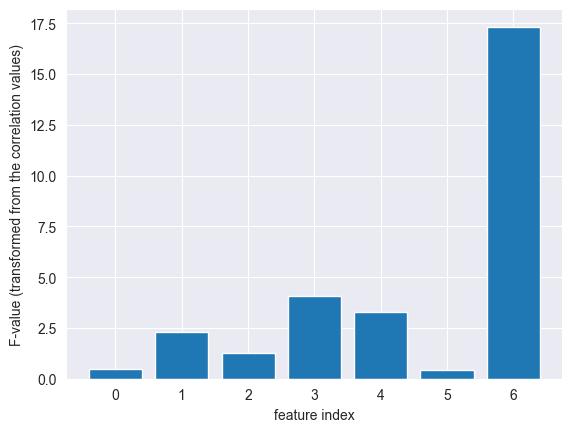

In [72]:
y = hatecrime['avg_hatecrimes_per_100k_fbi']
X = hatecrime[['share_unemployed_seasonal', 'share_population_in_metro_areas', 'share_population_with_high_school_degree',
               'share_non_citizen', 'share_white_poverty', 'share_non_white', 'share_voters_voted_trump']]
# Feature selection using the Correlation metric

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# feature selection
f_selector = SelectKBest(score_func=f_regression, k='all')
# learn relationship from training data
f_selector.fit(X_train, y_train)
# transform train input data
X_train_fs = f_selector.transform(X_train)
# transform test input data
X_test_fs = f_selector.transform(X_test)
# Plot the scores for the features
plt.bar([i for i in range(len(f_selector.scores_))], f_selector.scores_)
plt.xlabel("feature index")
plt.ylabel("F-value (transformed from the correlation values)")
plt.show()

In [73]:
X = hatecrime[['share_voters_voted_trump']]
X = sm.add_constant(X)
lr_model = sm.OLS(y, X).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     avg_hatecrimes_per_100k_fbi   R-squared:                       0.241
Model:                                     OLS   Adj. R-squared:                  0.226
Method:                          Least Squares   F-statistic:                     15.58
Date:                         Thu, 30 Oct 2025   Prob (F-statistic):           0.000252
Time:                                 22:05:18   Log-Likelihood:                -91.793
No. Observations:                           51   AIC:                             187.6
Df Residuals:                               49   BIC:                             191.5
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        5.8082      0.896      6.480      0.000       4.007       7.610
share_voters_voted_trump    -7.0215      1.779     -3.947      0.000     -10.596      -3.447
==============================================================================
Omnibus:                       16.561   Durbin-Watson:                   2.229
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.449
Skew:                           1.154   Prob(JB):                     2.20e-05
Kurtosis:                       5.184   Cond. No.                         10.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Q2-3 How does the number of hate crimes vary across states? Is there any similarity in number of hate incidents (per 100,000 people) between some states than in others — both according to the SPLC after the election and the FBI before it? [10 points]

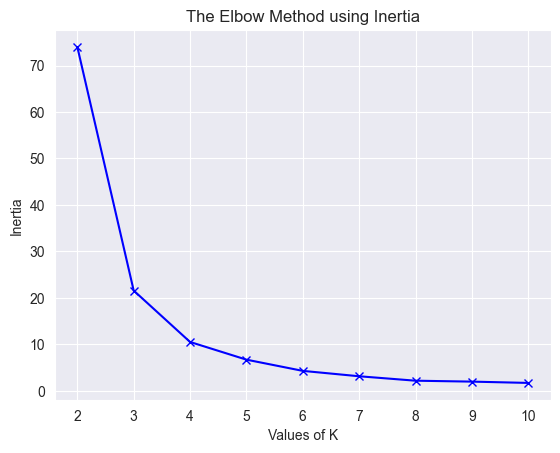

In [74]:
X = hatecrime[['avg_hatecrimes_per_100k_fbi', 'hate_crimes_per_100k_splc']]

inertias = []
for i in range(2, 11):
    km = KMeans(n_clusters=i).fit(X)
    inertias.append(km.inertia_)
    
    
plt.plot(range(2, 11), inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

In [75]:
## use kmean clustering to see the differences
data = hatecrime[['avg_hatecrimes_per_100k_fbi', 'hate_crimes_per_100k_splc']]
kmeans = KMeans(n_clusters=5)

# Fitting the model
pred_kmeans = kmeans.fit_predict(data)
centroids = kmeans.cluster_centers_

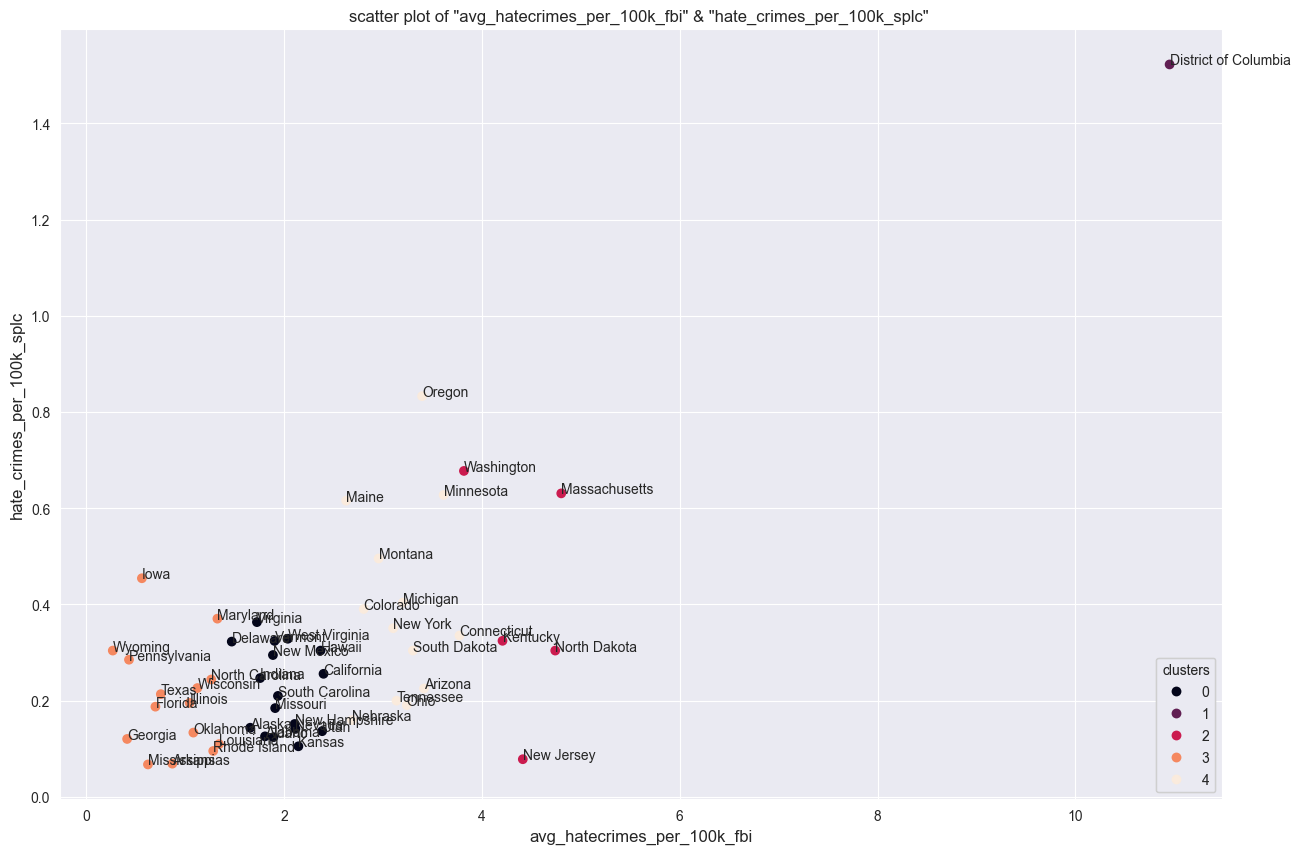

<Figure size 640x480 with 0 Axes>

In [76]:

fig, ax = plt.subplots(figsize=(15, 10))

scatter = plt.scatter(data['avg_hatecrimes_per_100k_fbi'], data['hate_crimes_per_100k_splc'], c=pred_kmeans) 
plt.xlabel('avg_hatecrimes_per_100k_fbi', fontsize=12) # Add x & y label, change font size
plt.ylabel('hate_crimes_per_100k_splc', fontsize=12)
legend = ax.legend(*scatter.legend_elements(),
                    loc="lower right", title="clusters")
ax.add_artist(legend)

state = hatecrime['state']
for i, s in enumerate(state):
    x = data['avg_hatecrimes_per_100k_fbi'][i]
    y = data['hate_crimes_per_100k_splc'][i]
    plt.text(x, y, s, fontsize=10)
plt.title("scatter plot of \"avg_hatecrimes_per_100k_fbi\" & \"hate_crimes_per_100k_splc\" ")
plt.figure()
plt.show()